# Week-1

# Linear Regression Example using tensorflow
Linear regression implementation with TensorFlow v2 library.

This example is using a low-level approach to better understand all mechanics behind the training process.


![image.png](attachment:image.png)

In [6]:
!pip install tensorflow

In [7]:
!pip install matplotlib

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
rng = np.random

![image.png](attachment:image.png)

In [9]:
learning_rate = 0.01
training_steps = 1000
display_step = 50

#### Just run the next cell using 'Ctrl' + 'Enter'

In [10]:
# Training Data.

X = np.array([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167,
              7.042,10.791,5.313,7.997,5.654,9.27,3.1])

Y = np.array([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221,
              2.827,3.465,1.65,2.904,2.42,2.94,1.3])

n_samples = X.shape[0]

![image.png](attachment:image.png)

In [11]:
print(X, '\n', X.shape)

[ 3.3    4.4    5.5    6.71   6.93   4.168  9.779  6.182  7.59   2.167
  7.042 10.791  5.313  7.997  5.654  9.27   3.1  ] 
 (17,)


![image.png](attachment:image.png)

In [12]:
print(Y, '\n', Y.shape)

[1.7   2.76  2.09  3.19  1.694 1.573 3.366 2.596 2.53  1.221 2.827 3.465
 1.65  2.904 2.42  2.94  1.3  ] 
 (17,)


![image.png](attachment:image.png)

In [13]:
W = tf.Variable(rng.randn(), name="weight")
b = tf.Variable(rng.randn(), name="bias")

![image.png](attachment:image.png)

In [14]:
def linear_regression(x):
    return W * x+b

![image.png](attachment:f8d55d15-2bc5-49f4-a5c1-6071f11b4d0f.png)

![image.png](attachment:2b0ecdab-a769-4555-9c5b-c8a96da3547b.png)

![image.png](attachment:image.png)

In [15]:
def mean_square(y_pred, y_true):
    return tf.reduce_sum(tf.pow(y_pred-y_true, 2)) / (2 * n_samples)

![image.png](attachment:image.png)

In [16]:
optimizer = tf.optimizers.SGD(learning_rate)

In [17]:
# Adding a question mark () after the function name lets you view the latest documentation.
# This is a handy tool.

![image.png](attachment:image.png)

In [18]:
tf.optimizers.SGD?

![image.png](attachment:image.png)

In [19]:
def run_optimization():

    #Wrap computation inside a GradientTape for autimatic differentiation
    with tf.GradientTape() as g:
        pred = linear_regression(X)
        loss = mean_square (pred, Y)

    #Compute gradients
    gradients = g.gradient(loss, [W, b])

    #Update W and b following gradients
    optimizer.apply_gradients (zip(gradients, [W, b]))

![image.png](attachment:image.png)

In [20]:
for step in range(1, training_steps + 1):

    #Run the optimization to update W and b values
    run_optimization()

    if step% display_step == 0:
        pred = linear_regression(X)
        loss = mean_square (pred, Y)

        print("step: %i, loss: %f, W: %f, b %f" % (step, loss, W.numpy(), b.numpy()))

step: 50, loss: 0.124207, W: 0.374908, b -0.075148
step: 100, loss: 0.118799, W: 0.367644, b -0.023654
step: 150, loss: 0.114011, W: 0.360809, b 0.024806
step: 200, loss: 0.109770, W: 0.354376, b 0.070410
step: 250, loss: 0.106014, W: 0.348323, b 0.113328
step: 300, loss: 0.102687, W: 0.342626, b 0.153717
step: 350, loss: 0.099741, W: 0.337265, b 0.191726
step: 400, loss: 0.097132, W: 0.332219, b 0.227495
step: 450, loss: 0.094821, W: 0.327471, b 0.261157
step: 500, loss: 0.092775, W: 0.323003, b 0.292836
step: 550, loss: 0.090963, W: 0.318798, b 0.322648
step: 600, loss: 0.089358, W: 0.314840, b 0.350704
step: 650, loss: 0.087936, W: 0.311116, b 0.377106
step: 700, loss: 0.086677, W: 0.307611, b 0.401953
step: 750, loss: 0.085562, W: 0.304313, b 0.425336
step: 800, loss: 0.084575, W: 0.301209, b 0.447341
step: 850, loss: 0.083700, W: 0.298288, b 0.468049
step: 900, loss: 0.082926, W: 0.295540, b 0.487537
step: 950, loss: 0.082240, W: 0.292953, b 0.505877
step: 1000, loss: 0.081633, W:

![image.png](attachment:image.png)

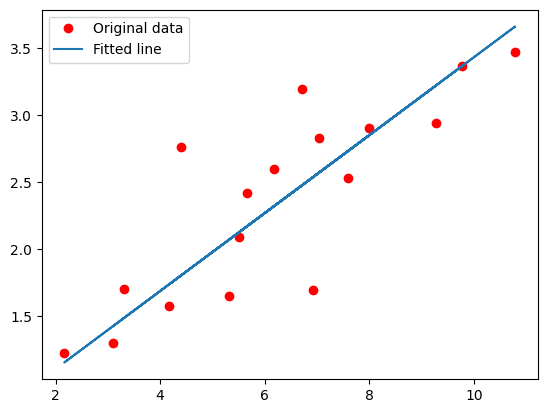

In [21]:
plt.plot(X, Y, 'ro', label='Original data')
plt.plot(X, np.array(W * X+b), label= 'Fitted line')
plt.legend()
plt.show()

# Lab Logbook requirements:
### Please make sure to document the following in your Lablogbook:

Include an image of the generated graph depicting the original data and the fitted line for linear regression. Modify the appearance of the graph by adjusting its color or size. Copy the figure and paste it directly into your logbook. Refrain from taking a snapshot; instead, right-click and copy the graph to your lab logbook. Ensure that no code or other information is added to the logbook and that only required graph is present.  

#### Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.

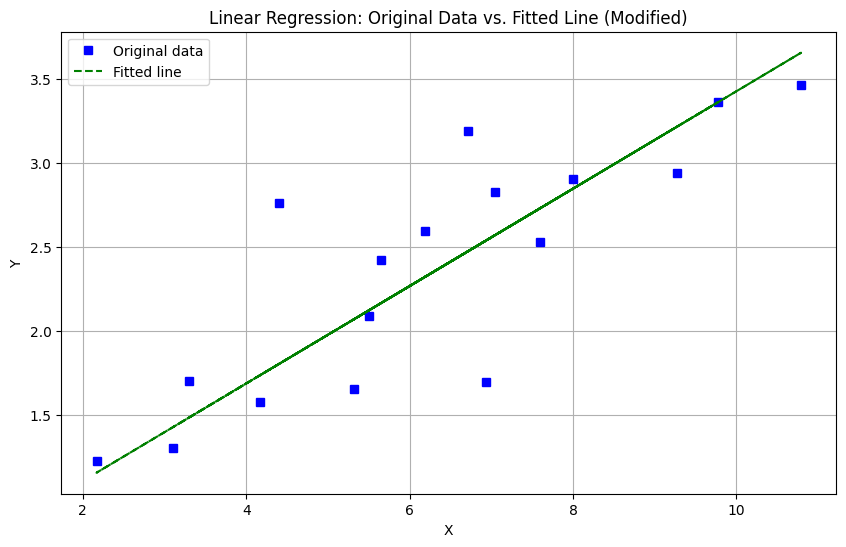

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(X, Y, 'bs', label='Original data') # 'bs' for blue squares
plt.plot(X, np.array(W * X + b), color='green', linestyle='--', label='Fitted line') # Green dashed line
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression: Original Data vs. Fitted Line (Modified)")
plt.legend()
plt.grid(True)
plt.show()